# Z distribution <hr style = "border:2.5px solid rgba(119, 65, 65, 1)"></hr>

<b> Griffin Vann L. Dymosco </b>
<br> Computer Engineering Technology

In [37]:
# Imports and Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [55]:
df = pd.read_csv(r"csv\transformer-voltage.csv",
                index_col = 'Sample',
                delimiter = ',')

df

,Voltage
Sample,
1,117.0
2,118.3
3,119.5
4,119.5
5,119.6
6,119.6
7,119.7
8,119.7
9,119.7


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 1 to 30
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Voltage  30 non-null     float64
dtypes: float64(1)
memory usage: 480.0 bytes


In [40]:
df.describe()

,Voltage
count,30.000000
mean,120.290000
std,1.243285
min,117.000000
25%,119.700000
50%,120.100000
75%,120.500000
max,123.800000


In [41]:
# z-critical for two-tailed test
#95%
alpha = 0.05
z_critical = stats.norm.ppf(1-alpha/2)
z_critical

np.float64(1.959963984540054)

In [42]:
# z-critical for two-tailed test
#99%
alpha = 0.01
z_critical = stats.norm.ppf(1-alpha/2)
z_critical

np.float64(2.5758293035489004)

In [43]:
# z-critical for two-tailed test
#100%
alpha = 0.0
z_critical = stats.norm.ppf(1-alpha/2)
z_critical

np.float64(inf)

In [56]:
# confidence interval
pop_std = 5

ci_lower, ci_upper = stats.norm.interval(
    confidence = 0.95,
    loc = df['Voltage'].mean(),
    scale = pop_std/np.sqrt(df['Voltage'].count())
)

print (f"CI = [{str(ci_lower)} , {str(ci_upper)}]")

CI = [118.50080585628282 , 122.07919414371713]


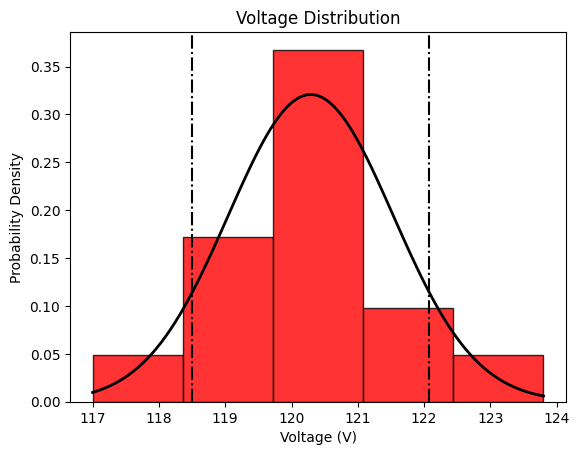

In [54]:
# voltage distribution

mean = df['Voltage'].mean()
std = df['Voltage'].std(ddof=1)

#x-axis
x_min = df['Voltage'].min()
x_max = df['Voltage'].max()

#normal distribution plot
x = np.linspace(x_min, x_max,100)
p = stats.norm.pdf(x, mean, std)
plt.plot(x,p,
        linewidth=2,
        color = "black")

#histogram
plt.hist(df['Voltage'],
         bins=5,
         density=True,
         alpha=0.8,
         color='red',
         edgecolor = 'black')

plt.title('Voltage Distribution')
plt.ylabel('Probability Density')
plt.xlabel('Voltage (V)')

#confidence interval
plt.axvline(x=ci_lower,
            color='black',
            linestyle='dashdot')

plt.axvline(x=ci_upper,
            color='black',
            linestyle='dashdot')

plt.show()